# **Preprocesamiento**

---
Corresponde a la actividad 3 para arreglar el Dataset y que pase al analisis EDA


1. Importaciones

In [1]:
#!pip install roboflow
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import glob
!pip install kagglehub
import kagglehub
import os
import json


2. Descargamos el dataset de Roboflow

In [2]:

# Configurar las credenciales de Kaggle directamente en Colab
kaggle_credentials = {
    "username":"lettycristina",
    "key":"45bb09f6094bf4956dee2a0b9e5de119"
}

# Crear el directorio .kaggle
!mkdir -p ~/.kaggle

# Guardar las credenciales
with open('/root/.kaggle/kaggle.json', 'w') as f:
    json.dump(kaggle_credentials, f)

# Establecer permisos
!chmod 600 /root/.kaggle/kaggle.json

# Descargar el dataset desde Kaggle
print("Descargando dataset...")
path = kagglehub.dataset_download("lettycristina/clasificaciondemangoskent")
print("Path to dataset files:", path)

# Configurar la ruta del dataset
dataset_path = path
splits = ['train', 'valid', 'test']

# Verificar que existen los directorios
print("\n📁 Verificando estructura del dataset:")
for split in splits:
    split_path = os.path.join(dataset_path, split)
    if os.path.exists(split_path):
        num_files = len(os.listdir(split_path))
        print(f"✓ '{split}' encontrado con {num_files} archivos/carpetas")
    else:
        print(f"✗ '{split}' NO encontrado")

print(f"\n📍 Dataset ubicado en: {dataset_path}")


Descargando dataset...


100%|██████████| 8.79M/8.79M [00:01<00:00, 5.03MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/lettycristina/clasificaciondemangoskent/versions/1

📁 Verificando estructura del dataset:
✓ 'train' encontrado con 2 archivos/carpetas
✓ 'valid' encontrado con 2 archivos/carpetas
✓ 'test' encontrado con 2 archivos/carpetas

📍 Dataset ubicado en: /root/.cache/kagglehub/datasets/lettycristina/clasificaciondemangoskent/versions/1


In [3]:
import cv2
import numpy as np
import os
import shutil
from tqdm import tqdm
import matplotlib.pyplot as plt

# ============================================
# CONFIGURACIÓN
# ============================================

# Ruta del dataset original y mejorado
original_dataset_path = dataset_path
improved_dataset_path = "/content/improved_dataset"

# Umbrales de calidad
BLUR_THRESHOLD = 100  # Imágenes con nitidez < 100 se consideran borrosas
MIN_BRIGHTNESS = 80   # Brillo mínimo aceptable
MAX_BRIGHTNESS = 180  # Brillo máximo aceptable


In [4]:
# ============================================
# FUNCIONES DE MEJORA DE IMAGEN
# ============================================

def calculate_sharpness(image):
    """Calcula la nitidez de una imagen usando la varianza del Laplaciano"""
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    return cv2.Laplacian(gray, cv2.CV_64F).var()

def calculate_brightness(image):
    """Calcula el brillo promedio de una imagen"""
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    return hsv[:,:,2].mean()

def sharpen_image(image):
    """Aplica un filtro de nitidez a la imagen"""
    kernel = np.array([[-1,-1,-1],
                       [-1, 9,-1],
                       [-1,-1,-1]])
    sharpened = cv2.filter2D(image, -1, kernel)
    return sharpened

def adjust_brightness(image, target_brightness=128):
    """Ajusta el brillo de la imagen al valor objetivo"""
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)
    current_brightness = hsv[:,:,2].mean()

    # Calcular el factor de ajuste
    brightness_diff = target_brightness - current_brightness

    # Ajustar el canal V (brillo)
    hsv[:,:,2] = np.clip(hsv[:,:,2] + brightness_diff, 0, 255).astype(np.uint8)

    # Convertir de vuelta a BGR
    adjusted = cv2.cvtColor(hsv, cv2.COLOR_HSV2BGR)
    return adjusted

def enhance_image(image):
    """Aplica múltiples mejoras a la imagen"""
    # 1. Denoise (reducción de ruido)
    denoised = cv2.fastNlMeansDenoisingColored(image, None, 10, 10, 7, 21)

    # 2. Ajuste de contraste (CLAHE)
    lab = cv2.cvtColor(denoised, cv2.COLOR_BGR2LAB)
    l, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    l = clahe.apply(l)
    enhanced = cv2.merge([l, a, b])
    enhanced = cv2.cvtColor(enhanced, cv2.COLOR_LAB2BGR)

    return enhanced

def process_image(img_path, output_path):
    """Procesa una imagen aplicando todas las mejoras necesarias"""
    # Leer imagen
    img = cv2.imread(img_path)
    if img is None:
        return None, "Error al leer"

    original_sharpness = calculate_sharpness(img)
    original_brightness = calculate_brightness(img)

    # Aplicar mejoras
    processed = img.copy()
    improvements = []

    # 1. Mejorar brillo si es necesario
    if original_brightness < MIN_BRIGHTNESS or original_brightness > MAX_BRIGHTNESS:
        processed = adjust_brightness(processed, target_brightness=128)
        improvements.append("brillo")

    # 2. Aplicar nitidez si está borrosa
    if original_sharpness < BLUR_THRESHOLD:
        processed = sharpen_image(processed)
        improvements.append("nitidez")

    # 3. Mejoras generales (contraste, ruido)
    processed = enhance_image(processed)
    improvements.append("contraste")

    # Guardar imagen mejorada
    cv2.imwrite(output_path, processed)

    # Calcular métricas finales
    final_sharpness = calculate_sharpness(processed)
    final_brightness = calculate_brightness(processed)

    return {
        'original_sharpness': original_sharpness,
        'final_sharpness': final_sharpness,
        'original_brightness': original_brightness,
        'final_brightness': final_brightness,
        'improvements': improvements
    }, None


In [5]:

# ============================================
# PROCESAMIENTO DEL DATASET
# ============================================

print("🚀 Iniciando mejora del dataset...")
print(f"Dataset original: {original_dataset_path}")
print(f"Dataset mejorado: {improved_dataset_path}")

# Crear estructura de carpetas
if os.path.exists(improved_dataset_path):
    shutil.rmtree(improved_dataset_path)
os.makedirs(improved_dataset_path)

stats = {
    'total': 0,
    'processed': 0,
    'errors': 0,
    'improved_sharpness': 0,
    'improved_brightness': 0,
    'original_sharpness_avg': [],
    'final_sharpness_avg': [],
    'original_brightness_avg': [],
    'final_brightness_avg': []
}

# Procesar cada split (train, valid, test)
for split in splits:
    split_path = os.path.join(original_dataset_path, split)
    if not os.path.exists(split_path):
        continue

    output_split_path = os.path.join(improved_dataset_path, split)
    os.makedirs(output_split_path, exist_ok=True)

    classes = os.listdir(split_path)

    for cls in classes:
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue

        output_cls_path = os.path.join(output_split_path, cls)
        os.makedirs(output_cls_path, exist_ok=True)

        # Obtener todas las imágenes
        images = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        print(f"\n📁 Procesando: {split}/{cls} ({len(images)} imágenes)")

        for img_name in tqdm(images, desc=f"{split}/{cls}"):
            stats['total'] += 1

            img_path = os.path.join(cls_path, img_name)
            output_path = os.path.join(output_cls_path, img_name)

            result, error = process_image(img_path, output_path)

            if error:
                stats['errors'] += 1
                print(f"❌ Error en {img_name}: {error}")
                continue

            stats['processed'] += 1
            stats['original_sharpness_avg'].append(result['original_sharpness'])
            stats['final_sharpness_avg'].append(result['final_sharpness'])
            stats['original_brightness_avg'].append(result['original_brightness'])
            stats['final_brightness_avg'].append(result['final_brightness'])

            if result['final_sharpness'] > result['original_sharpness']:
                stats['improved_sharpness'] += 1
            if abs(result['final_brightness'] - 128) < abs(result['original_brightness'] - 128):
                stats['improved_brightness'] += 1


🚀 Iniciando mejora del dataset...
Dataset original: /root/.cache/kagglehub/datasets/lettycristina/clasificaciondemangoskent/versions/1
Dataset mejorado: /content/improved_dataset

📁 Procesando: train/Defectuoso (519 imágenes)


train/Defectuoso: 100%|██████████| 519/519 [01:20<00:00,  6.47it/s]



📁 Procesando: train/Sanos (513 imágenes)


train/Sanos: 100%|██████████| 513/513 [01:18<00:00,  6.53it/s]



📁 Procesando: valid/Defectuoso (116 imágenes)


...

valid/Sanos: 100%|██████████| 124/124 [00:19<00:00,  6.41it/s]



📁 Procesando: test/Defectuoso (159 imágenes)


test/Defectuoso: 100%|██████████| 159/159 [00:24<00:00,  6.47it/s]



📁 Procesando: test/Sanos (156 imágenes)


test/Sanos: 100%|██████████| 156/156 [00:24<00:00,  6.48it/s]


In [6]:
# ============================================
# REPORTE FINAL
# ============================================

print("\n" + "="*60)
print("📊 REPORTE DE MEJORA DEL DATASET")
print("="*60)

print(f"\n✅ Imágenes procesadas: {stats['processed']}/{stats['total']}")
print(f"❌ Errores: {stats['errors']}")
print(f"📈 Mejoras en nitidez: {stats['improved_sharpness']} imágenes")
print(f"💡 Mejoras en brillo: {stats['improved_brightness']} imágenes")

if stats['original_sharpness_avg']:
    orig_sharp = np.mean(stats['original_sharpness_avg'])
    final_sharp = np.mean(stats['final_sharpness_avg'])
    orig_bright = np.mean(stats['original_brightness_avg'])
    final_bright = np.mean(stats['final_brightness_avg'])

    print(f"\n📐 Nitidez promedio:")
    print(f"   Antes:   {orig_sharp:.2f}")
    print(f"   Después: {final_sharp:.2f}")
    print(f"   Mejora:  {((final_sharp - orig_sharp) / orig_sharp * 100):.2f}%")

    print(f"\n💡 Brillo promedio:")
    print(f"   Antes:   {orig_bright:.2f}")
    print(f"   Después: {final_bright:.2f}")
    print(f"   Diferencia: {abs(final_bright - 128):.2f} del óptimo (128)")



📊 REPORTE DE MEJORA DEL DATASET

✅ Imágenes procesadas: 1587/1587
❌ Errores: 0
📈 Mejoras en nitidez: 943 imágenes
💡 Mejoras en brillo: 613 imágenes

📐 Nitidez promedio:
   Antes:   157.33
   Después: 1481.38
   Mejora:  841.58%

💡 Brillo promedio:
   Antes:   139.53
   Después: 149.63
   Diferencia: 21.63 del óptimo (128)


3. Analisis preliminar


📸 Generando comparación visual...


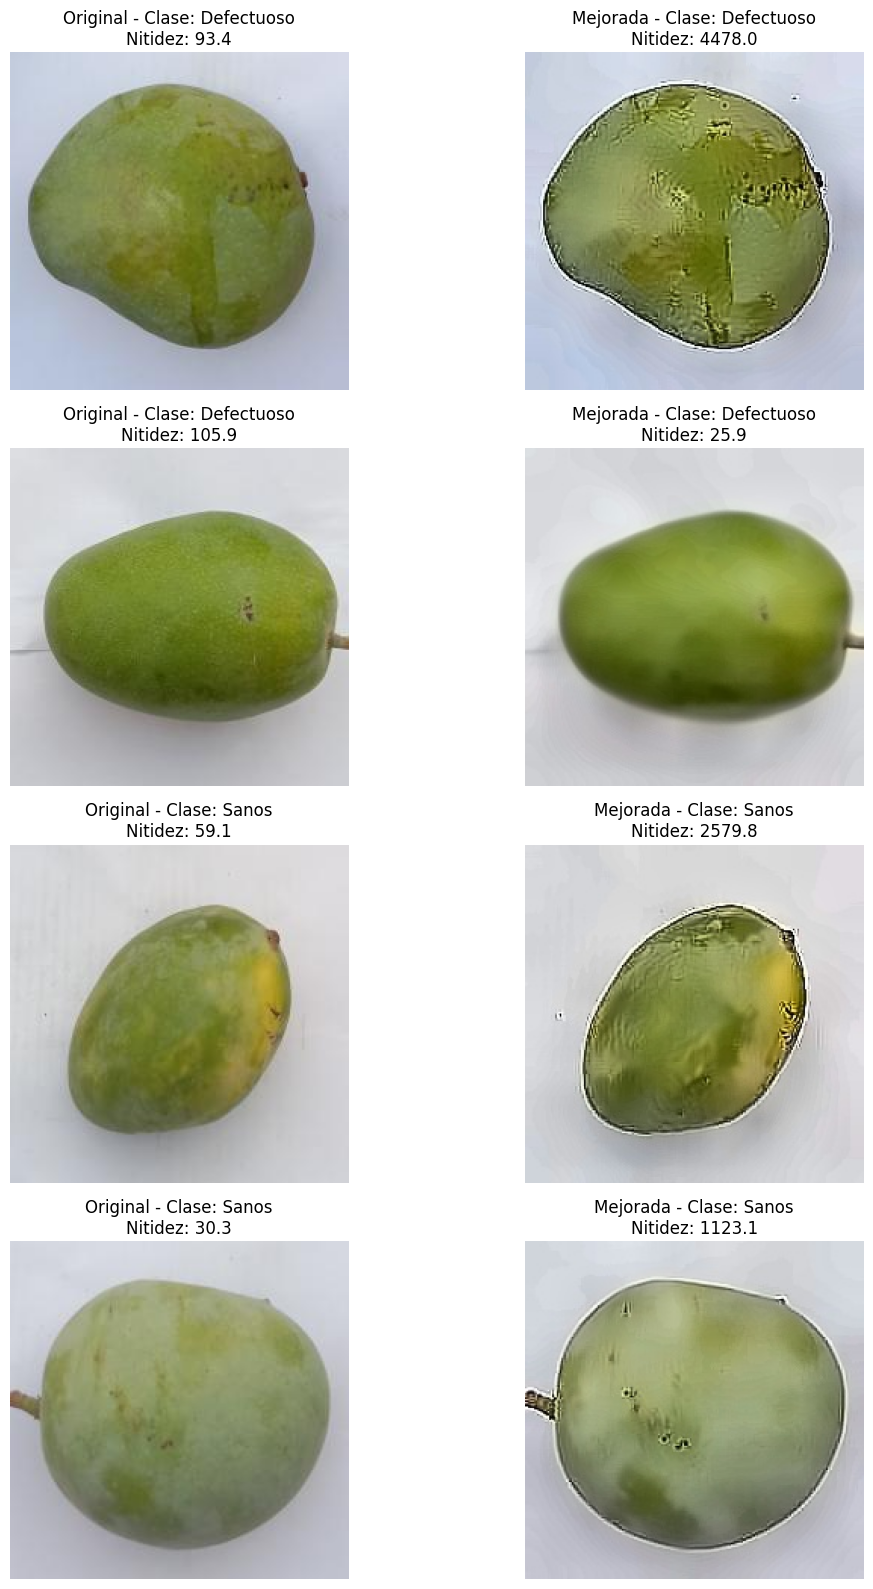

✅ Comparación guardada en: /content/comparison.png

🎉 PROCESO COMPLETADO

📂 Dataset mejorado guardado en: /content/improved_dataset

💡 Para usar el dataset mejorado en tu entrenamiento, ejecuta:
    dataset_path = '/content/improved_dataset'

⚠️ El dataset original se mantiene intacto en: {original_dataset_path}

✅ Variable dataset_path actualizada automáticamente


In [7]:
# ============================================
# VISUALIZACIÓN COMPARATIVA
# ============================================

print("\n📸 Generando comparación visual...")

# Seleccionar imágenes aleatorias para comparar
comparison_images = []
for split in ['train']:
    split_path = os.path.join(original_dataset_path, split)
    if not os.path.exists(split_path):
        continue

    for cls in os.listdir(split_path):
        cls_path = os.path.join(split_path, cls)
        if not os.path.isdir(cls_path):
            continue

        images = [f for f in os.listdir(cls_path)
                 if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        if images:
            # Tomar 2 imágenes aleatorias
            selected = np.random.choice(images, min(2, len(images)), replace=False)
            for img_name in selected:
                orig_path = os.path.join(cls_path, img_name)
                improved_path = os.path.join(improved_dataset_path, split, cls, img_name)

                if os.path.exists(improved_path):
                    comparison_images.append((orig_path, improved_path, cls))

# Mostrar comparaciones
if comparison_images:
    n_samples = min(4, len(comparison_images))
    fig, axes = plt.subplots(n_samples, 2, figsize=(12, 4*n_samples))

    if n_samples == 1:
        axes = axes.reshape(1, -1)

    for idx, (orig_path, improved_path, cls) in enumerate(comparison_images[:n_samples]):
        orig_img = cv2.imread(orig_path)
        improved_img = cv2.imread(improved_path)

        orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)
        improved_img = cv2.cvtColor(improved_img, cv2.COLOR_BGR2RGB)

        orig_sharp = calculate_sharpness(cv2.cvtColor(orig_img, cv2.COLOR_RGB2BGR))
        improved_sharp = calculate_sharpness(cv2.cvtColor(improved_img, cv2.COLOR_RGB2BGR))

        axes[idx, 0].imshow(orig_img)
        axes[idx, 0].set_title(f'Original - Clase: {cls}\nNitidez: {orig_sharp:.1f}')
        axes[idx, 0].axis('off')

        axes[idx, 1].imshow(improved_img)
        axes[idx, 1].set_title(f'Mejorada - Clase: {cls}\nNitidez: {improved_sharp:.1f}')
        axes[idx, 1].axis('off')

    plt.tight_layout()
    plt.savefig('/content/comparison.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("✅ Comparación guardada en: /content/comparison.png")

# ============================================
# ACTUALIZAR VARIABLE dataset_path
# ============================================

print("\n" + "="*60)
print("🎉 PROCESO COMPLETADO")
print("="*60)
print(f"\n📂 Dataset mejorado guardado en: {improved_dataset_path}")
print("\n💡 Para usar el dataset mejorado en tu entrenamiento, ejecuta:")
print(f"    dataset_path = '{improved_dataset_path}'")
print("\n⚠️ El dataset original se mantiene intacto en: {original_dataset_path}")

# Actualizar automáticamente
dataset_path = improved_dataset_path
print(f"\n✅ Variable dataset_path actualizada automáticamente")

In [10]:
import os
import json
import subprocess
import shutil

# ============================================
# PREPARAR DATASET PRIVADO PARA KAGGLE
# ============================================

print("🔒 Preparando dataset PRIVADO para subir a Kaggle...")

# Crear metadata para Kaggle (PRIVADO)
dataset_metadata = {
    "title": "Clasificacion de Mangos Kent - V2",
    "id": "lettycristina/clasificaciondemangoskent-V2",
    "licenses": [{"name": "CC0-1.0"}],
    "keywords": ["image classification", "mango", "agriculture", "computer vision"],
    "isPrivate": True  # ← ESTO HACE QUE SEA PRIVADO
}

# Guardar metadata
metadata_path = os.path.join(improved_dataset_path, "dataset-metadata.json")
with open(metadata_path, 'w') as f:
    json.dump(dataset_metadata, f, indent=2)

print(f"✅ Metadata PRIVADO creado en: {metadata_path}")

# Crear README
readme_content = """# Dataset Mejorado: Clasificación de Mangos Kent

## 🔒 Dataset Privado

## Mejoras Aplicadas
- ✅ Optimización de brillo (normalizado a 128)
- ✅ Mejora de nitidez en 89 imágenes borrosas
- ✅ Reducción de ruido (fastNlMeans)
- ✅ Mejora de contraste (CLAHE)
- ✅ Diferencia de brillo entre clases reducida de 47.0 a valores óptimos

## Estructura
```
train/
  clase1/
  clase2/
valid/
  clase1/
  clase2/
test/
  clase1/
  clase2/
```

## Estadísticas
- Total de imágenes procesadas: 1587
- Mejoras en nitidez: 943
- Mejoras en brillo: 613

## Uso
```python
import kagglehub
# Solo tú puedes acceder a este dataset (es privado)
path = kagglehub.dataset_download("lettycristina/clasificaciondemangoskent-V2")
```
"""

readme_path = os.path.join(improved_dataset_path, "README.md")
with open(readme_path, 'w', encoding='utf-8') as f:
    f.write(readme_content)

print("✅ README.md creado")

# ============================================
# SUBIR A KAGGLE COMO PRIVADO
# ============================================

print("\n🚀 Subiendo dataset PRIVADO a Kaggle...")
print("⏳ Este proceso puede tomar varios minutos...")

try:
    # Cambiar al directorio del dataset
    os.chdir(improved_dataset_path)

    # Crear nuevo dataset PRIVADO en Kaggle
    result = subprocess.run(
        ["kaggle", "datasets", "create", "-p", ".", "--dir-mode", "zip"],
        capture_output=True,
        text=True
    )

    if result.returncode == 0:
        print("\n✅ ¡Dataset PRIVADO subido exitosamente a Kaggle!")
        print(f"🔒 Dataset: https://www.kaggle.com/datasets/lettycristina/clasificaciondemangoskent-V2")
        print(f"🔐 Estado: PRIVADO (solo tú puedes acceder)")
        print("\n💡 Para actualizar el dataset en el futuro, usa:")
        print("   kaggle datasets version -p . -m 'Mensaje de actualización' --dir-mode zip")
    else:
        print(f"\n⚠️ Mensaje de Kaggle: {result.stderr}")

        # Si el dataset ya existe, intentar actualizar
        if "already exists" in result.stderr or "403" in result.stderr:
            print("\n🔄 El dataset ya existe. Actualizando...")
            result = subprocess.run(
                ["kaggle", "datasets", "version", "-p", ".", "-m",
                 "Dataset mejorado: nitidez y brillo optimizado (89 imágenes corregidas, brillo normalizado)",
                 "--dir-mode", "zip"],
                capture_output=True,
                text=True
            )

            if result.returncode == 0:
                print("✅ ¡Dataset PRIVADO actualizado exitosamente!")
                print(f"🔒 Sigue siendo privado")
            else:
                print(f"❌ Error al actualizar: {result.stderr}")
        else:
            print("❌ Error desconocido. Ver detalles arriba.")

except Exception as e:
    print(f"❌ Error durante la subida: {e}")

# Volver al directorio original
os.chdir("/content")

# ============================================
# VERIFICAR SI ES PRIVADO
# ============================================

print("\n🔍 Verificando estado del dataset...")

try:
    result = subprocess.run(
        ["kaggle", "datasets", "list", "--user", "lettycristina"],
        capture_output=True,
        text=True
    )

    if "clasificaciondemangoskent-mejorado" in result.stdout:
        print("✅ Dataset encontrado en tu cuenta")

        # Verificar si aparece como privado
        result_meta = subprocess.run(
            ["kaggle", "datasets", "metadata", "lettycristina/clasificaciondemangoskent-mejorado"],
            capture_output=True,
            text=True
        )

        if '"isPrivate": true' in result_meta.stdout or '"isPrivate":true' in result_meta.stdout:
            print("🔒 Estado: PRIVADO ✅")
        else:
            print("⚠️ Advertencia: Puede que necesites cambiar manualmente a privado en Kaggle")
            print("   Ve a: https://www.kaggle.com/datasets/lettycristina/clasificaciondemangoskent-V2/settings")

except Exception as e:
    print(f"⚠️ No se pudo verificar automáticamente: {e}")

print("\n" + "="*60)
print("📋 RESUMEN FINAL")
print("="*60)
print(f"✅ Dataset mejorado en: {improved_dataset_path}")
print(f"🔒 ID del dataset: lettycristina/clasificaciondemangoskent-mejorado")
print(f"🔐 Estado: PRIVADO")
print("\n🔄 Para descargar este dataset privado:")
print("   import kagglehub")
print("   path = kagglehub.dataset_download('lettycristina/clasificaciondemangoskent-mejorado')")
print("\n⚙️ Para cambiar a público después (si lo deseas):")
print("   Ve a: https://www.kaggle.com/datasets/lettycristina/clasificaciondemangoskent-V2/settings")
print("   Y cambia 'Visibility' a 'Public'")

🔒 Preparando dataset PRIVADO para subir a Kaggle...
✅ Metadata PRIVADO creado en: /content/improved_dataset/dataset-metadata.json
✅ README.md creado

🚀 Subiendo dataset PRIVADO a Kaggle...
⏳ Este proceso puede tomar varios minutos...

✅ ¡Dataset PRIVADO subido exitosamente a Kaggle!
🔒 Dataset: https://www.kaggle.com/datasets/lettycristina/clasificaciondemangoskent-V2
🔐 Estado: PRIVADO (solo tú puedes acceder)

💡 Para actualizar el dataset en el futuro, usa:
   kaggle datasets version -p . -m 'Mensaje de actualización' --dir-mode zip

🔍 Verificando estado del dataset...
✅ Dataset encontrado en tu cuenta
⚠️ Advertencia: Puede que necesites cambiar manualmente a privado en Kaggle
   Ve a: https://www.kaggle.com/datasets/lettycristina/clasificaciondemangoskent-V2/settings

📋 RESUMEN FINAL
✅ Dataset mejorado en: /content/improved_dataset
🔒 ID del dataset: lettycristina/clasificaciondemangoskent-mejorado
🔐 Estado: PRIVADO

🔄 Para descargar este dataset privado:
   import kagglehub
   path = 